In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import pandas as pd
import seaborn as sns
from collections import Counter

In [2]:
base_dir = '../../'
cell_table_path=base_dir+'segmentation/cell_table_contrast_adj/cell_table_size_normalized.csv'
biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response_RCB.csv'
cell_table = pd.read_csv(cell_table_path,index_col=False)
biosamples =pd.read_csv(biosamples_path)
biosamples.drop(['FORCE_TRIAL?_(Y/N)',"H&E_NOTES"],axis = 1,inplace = True) #they are empty columns
intensities_protein = cell_table.iloc[:,1:cell_table.columns.get_loc('label')]#proteins are from the second columns up to the column called 
adata = sc.AnnData(intensities_protein, obsm={"spatial": cell_table[['centroid-0', 'centroid-1']].values})
adata.obs['acquisition_ID'] = cell_table.fov.values
adata.obs['Leap_ID'] = adata.obs.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
adata.obs['Leap_ID'] = adata.obs.Leap_ID.str[:7]#leap_ID should be Leap123, anything more is stripped
adata.obs = adata.obs.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1).set_index('index')
adata.X[np.isnan(adata.X)] =0
#sc.pp.log1p(adata,copy = False)

/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [28]:
sc.pp.neighbors(adata, n_neighbors=10, method = 'rapids')
sc.tl.umap(adata,method = 'rapids')

/home/giuseppe/anaconda3/envs/rapids-23.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


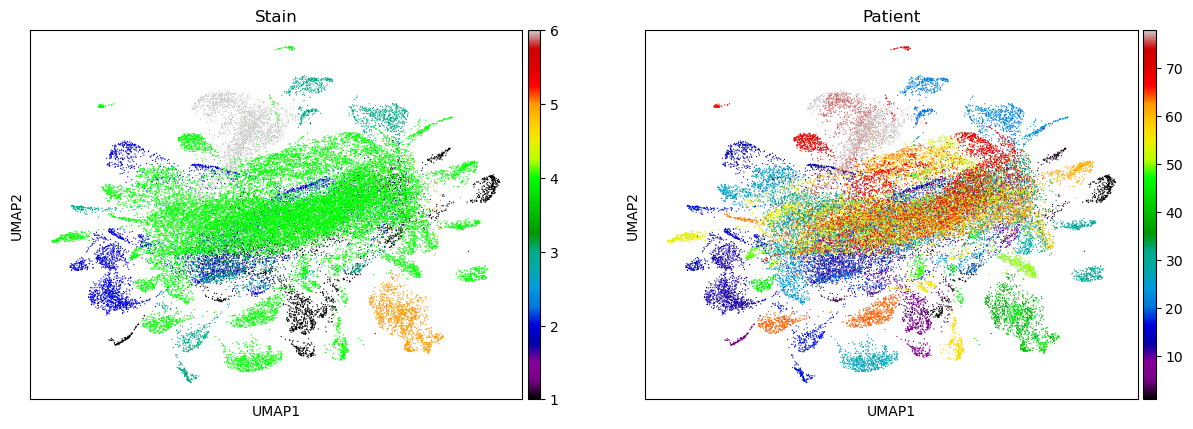

In [60]:
a = sc.pl.umap(adata[::100],color = ['Stain','Patient'],return_fig=True,cmap='nipy_spectral')

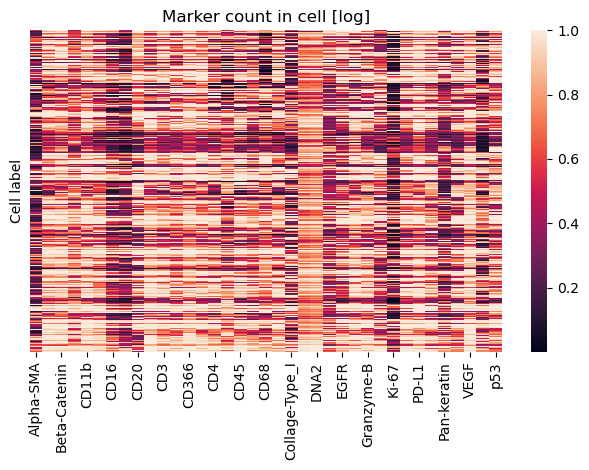

In [61]:
sns.heatmap(pd.DataFrame(adata[:,adata.var.index!='Carboplatin'].X[::10],columns = adata.var.index[adata.var.index!='Carboplatin']))
plt.yticks([], [])
plt.ylabel('Cell label')
plt.title('Marker count in cell [log]')
plt.tight_layout()
#plt.savefig('figures/cell_by_marker_hm.png')

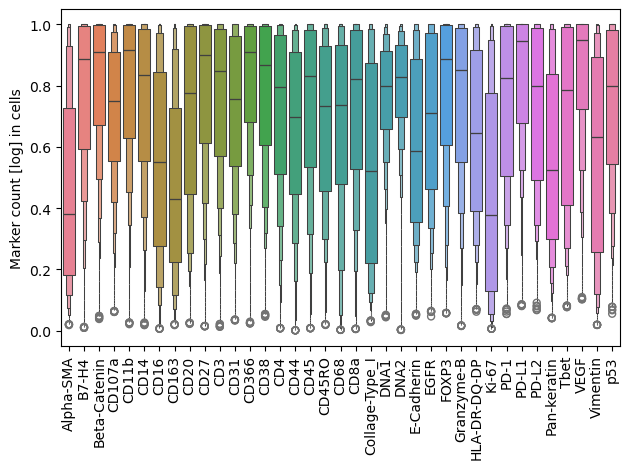

In [62]:
sns.boxenplot(pd.DataFrame(adata[:,adata.var.index!='Carboplatin'].X[::10],columns = adata.var.index[adata.var.index!='Carboplatin']))
_ = plt.xticks(rotation = 90)
plt.ylabel('Marker count [log] in cells')
plt.tight_layout()
#plt.savefig('figures/marker_in_cell_distribution.png')

<Figure size 640x480 with 0 Axes>

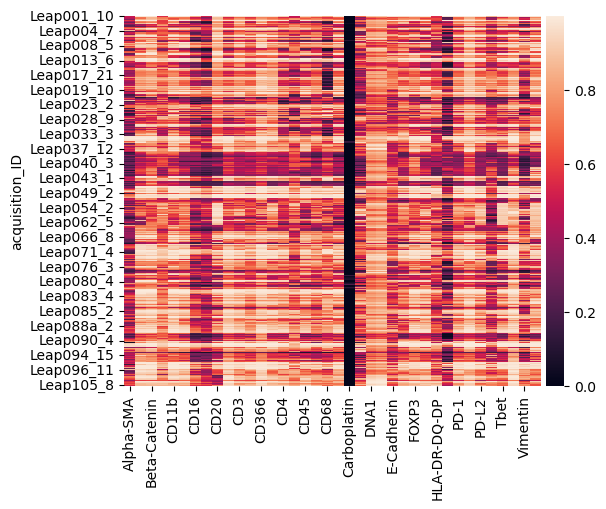

<Figure size 640x480 with 0 Axes>

In [63]:
sns.heatmap(data,cbar_kws={'pad':0.01})
plt.figure()
#data.iloc[:,~adata.var.index.isin(['Carboplatin','DNA1','DNA2'])].sum(axis = 1).hist()


<Axes: xlabel='None-None', ylabel='Leap_ID'>

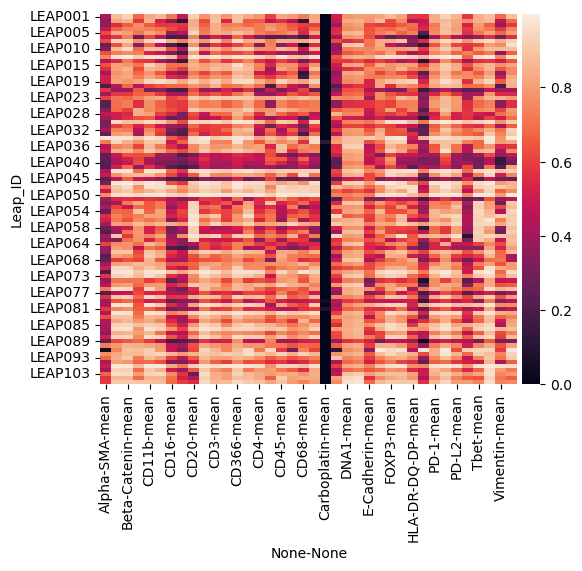

In [66]:
d = pd.DataFrame(adata.X, columns = adata.var.index, index=adata.obs.Leap_ID).sort_index()
#d = d.iloc[:,~d.columns.isin(['Carboplatin', 'Collage-Type_I', 'DNA1', 'DNA2', 'p53', 'VEGF', 'EGFR', 'Ki-67', 'PD-1', 'PD-L1', 'PD-L2'])]
data = d.groupby(by = ['Leap_ID'],observed = True).agg({'mean'})
sns.heatmap(data,cbar_kws={'pad':0.01})

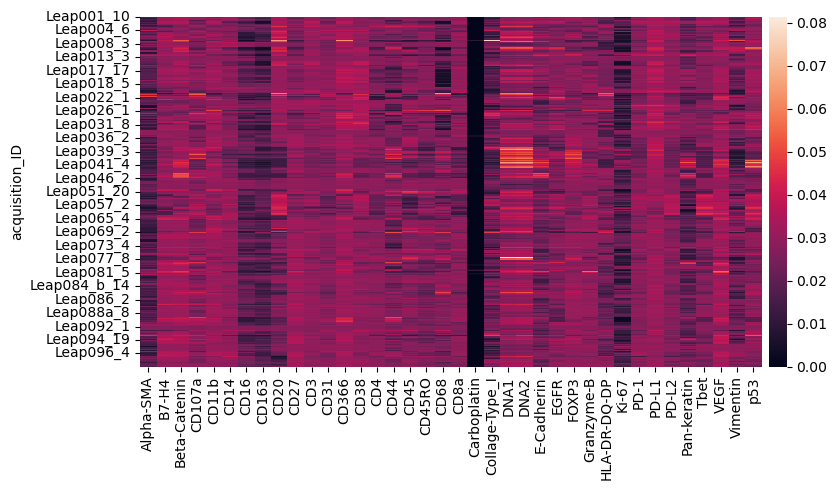

In [10]:
plt.figure(figsize = (9,5))
d = pd.DataFrame(adata.X, columns = adata.var.index, index=adata.obs.acquisition_ID).sort_index()
#d = d.iloc[:,~d.columns.isin(['Carboplatin', 'Collage-Type_I', 'DNA1', 'DNA2', 'p53', 'VEGF', 'EGFR', 'Ki-67', 'PD-1', 'PD-L1', 'PD-L2'])]
data = d.groupby(by = ['acquisition_ID'],observed = True).agg({'mean'})#,lambda x:np.percentile(x,0.975)-np.percentile(x,0.025)})
data.columns = list(map(lambda x:x[0],data.columns))
denominator = data.sum(axis = 1)
sns.heatmap(data.div(denominator,axis = 0),cbar_kws={'pad':0.01})
ax = plt.gca()
labels = [item.get_text().replace('-mean','') for item in ax.get_xticklabels()]
_ = ax.set_xticklabels(labels)
plt.tight_layout()
#plt.savefig('figures/ROI_by_marker.png')

In [23]:
sc.pp.neighbors(adata, n_neighbors=10, method = 'rapids')
sc.tl.umap(adata,method = 'rapids')


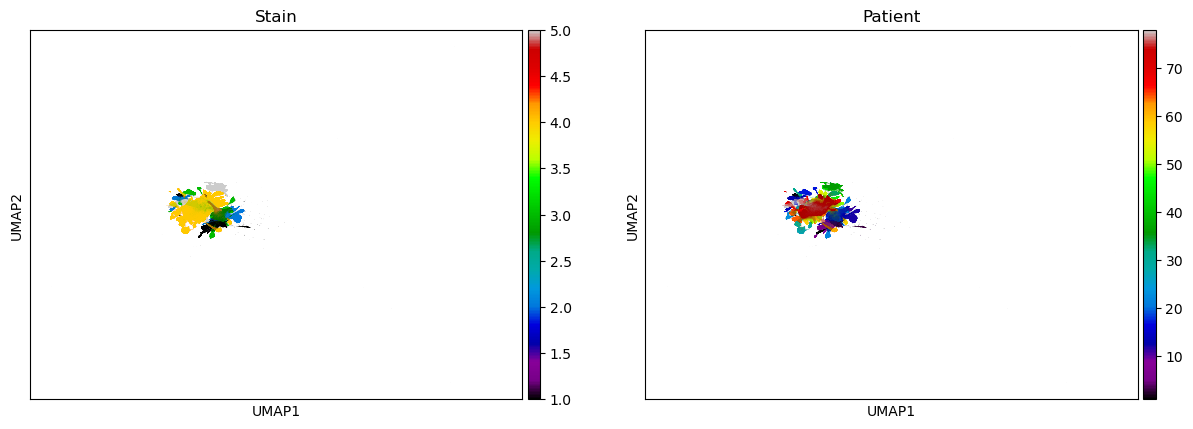

In [33]:
a  = sc.pl.umap(adata,color = ['Stain','Patient'],return_fig=True,cmap='nipy_spectral')


In [31]:
np.max(adata.obsm['X_umap'],axis = 0),np.min(adata.obsm['X_umap'],axis = 0)

(array([138.12808 , 110.201294], dtype=float32),
 array([ -70.78697, -116.27545], dtype=float32))

In [17]:
adata.obs

,acquisition_ID,Leap_ID,SLIDE_NUMBER,BIOBANK_ID,SAMPLE_TYPE_(CORE/RESECTION),FORMAT_(FFPE/FROZEN),DATE_SECTIONED,ST_NOTES,Response,COMMENTS,new_Response,Patient
index,,,,,,,,,,,,
0,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,21/06/2022,NaN,Non-Responder,CORE,nR,1
1,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,21/06/2022,NaN,Non-Responder,CORE,nR,1
2,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,21/06/2022,NaN,Non-Responder,CORE,nR,1
3,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,21/06/2022,NaN,Non-Responder,CORE,nR,1
4,Leap001_10,LEAP001,1.0,19005858-FPE US (C)-1-FPEDiv-1,CORE,FFPE,21/06/2022,NaN,Non-Responder,CORE,nR,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3738841,Leap105_9,LEAP105,42.0,22003388-FPE US (C)-1-FPEDiv-1,CORE,FFPE,2023-05-16 00:00:00,NaN,pCR,CORE,pCR,78
3738842,Leap105_9,LEAP105,42.0,22003388-FPE US (C)-1-FPEDiv-1,CORE,FFPE,2023-05-16 00:00:00,NaN,pCR,CORE,pCR,78
3738843,Leap105_9,LEAP105,42.0,22003388-FPE US (C)-1-FPEDiv-1,CORE,FFPE,2023-05-16 00:00:00,NaN,pCR,CORE,pCR,78


In [6]:
def discretise(data,thr):
    '''binarise the counts to 0/1'''
    if isinstance(data, sc.AnnData):
        return data.X>thr
    else:
        return data>thr
def normalise(adata,quantile=0.95):
    if isinstance(adata, sc.AnnData):
        data =  adata.copy().X
    else:
        data = adata.copy()
    if np.all(data<1):
        logger.warning('data seem already normalised, skipping normalisation')
        return adata
    q = np.quantile(data,q = quantile,axis = 0)
    data = data/q
    data[data>1] = 1
    if isinstance(adata, sc.AnnData):
        adata.X = data
        return adata
    else:
        return data
def quality_control(intensities,low_gene_active = 0.2,high_gene_active = 0.5):
    if 'pass_qc' in intensities.columns:
        return intensities['pass_qc']
    intensities_protein = intensities.iloc[:,1:intensities.columns.get_loc('label')]#proteins are from the second columns up to the column called label
    markers_4_phenotyping = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
    intensities_protein =    normalise(intensities_protein,0.95)
    A = intensities_protein.loc[:,markers_4_phenotyping]
    cond_few_genes_in_cell  = np.sum(discretise(A,thr = low_gene_active),axis=1)>0
    cond_many_genes_in_cell  = np.sum(discretise(A,thr = high_gene_active),axis=1)<11
    dna_count = intensities_protein[['DNA1', 'DNA2']].sum(axis = 1)
    dna_thr = np.quantile(dna_count,0.05)
    dna_cond = dna_count>dna_thr
    cond = cond_few_genes_in_cell& cond_many_genes_in_cell&dna_cond
    return cond


In [7]:
qc_pass = quality_control(intensities)


In [12]:
intensities['qc_pass'] = qc_pass

In [4]:
intensities_protein

,Alpha-SMA,B7-H4,Beta-Catenin,CD107a,CD11b,CD14,CD16,CD163,CD20,CD27,...,HLA-DR-DQ-DP,Ki-67,PD-1,PD-L1,PD-L2,Pan-keratin,Tbet,VEGF,Vimentin,p53
0,0.264638,0.192693,0.604622,0.519856,0.705861,0.459095,0.718540,0.595334,0.503627,0.658462,...,0.508419,0.194048,0.046928,0.731710,0.077818,0.126584,0.421740,0.422248,0.609661,0.487910
1,0.076969,0.584373,0.341482,0.852226,0.629407,0.879049,0.953706,0.929127,0.662462,0.692608,...,0.878676,0.219241,0.508170,0.885254,0.430096,0.243676,0.876586,0.486317,0.970708,0.229305
2,0.018010,0.298134,0.164114,0.053308,0.251712,0.227312,0.185779,0.047499,0.346541,0.177957,...,0.090187,0.272537,0.184891,0.309375,0.382481,0.368001,0.148677,0.168146,0.174642,0.294479
3,0.060798,0.877243,0.847850,0.188305,0.650574,0.372345,0.420883,0.250830,0.640458,0.781065,...,0.115603,0.109292,0.321500,0.887931,0.831892,0.794518,0.570623,0.634680,0.695144,0.559728
4,0.066522,0.582359,0.316132,0.430911,0.670231,0.832804,0.489699,0.172650,0.230090,0.688186,...,0.236755,0.158866,0.365910,0.711813,0.624026,0.609915,0.282110,0.238929,0.367302,0.375385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3683192,0.027200,0.376295,0.203559,0.398073,0.429921,0.370777,0.379383,0.363103,0.118641,0.284913,...,0.314794,0.131901,0.128844,0.350803,0.207857,0.111590,0.106315,0.266793,0.388682,0.255131
3683193,0.128809,0.455043,0.332670,0.520309,0.619617,0.618442,0.814067,0.496920,0.025098,0.576242,...,0.271425,0.048983,0.161998,0.286226,0.339286,0.094936,0.653320,0.526519,0.178844,0.832122
3683194,0.214880,0.336149,0.248854,0.280274,0.333964,0.440988,0.216012,0.195966,0.090431,0.282147,...,0.053728,0.157601,0.826124,0.219095,0.497780,0.126661,0.428888,0.504595,0.423855,0.902232
3683195,0.011888,0.407592,0.368088,0.256903,0.359419,0.193805,0.299558,0.131650,0.016079,0.543742,...,0.104803,0.082742,0.680835,0.354258,0.462548,0.125523,0.423365,0.553834,0.179735,0.552082


In [7]:
low_gene_active = 0.2
high_gene_active = 0.5
intensities = intensities_protein
markers_4_phenotyping = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
   'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
   'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
   'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
   'CD3', 'CD27', 'CD45RO',
   'Alpha-SMA', 'Vimentin', 'CD31' ]

A = intensities_protein.loc[:,markers_4_phenotyping]
cond_few_genes_in_cell  = np.sum(discretise(A,thr = low_gene_active),axis=1)>0
cond_many_genes_in_cell  = np.sum(discretise(A,thr = high_gene_active),axis=1)<11

cond = cond_few_genes_in_cell& cond_many_genes_in_cell


In [8]:
dna_count = intensities_protein[['DNA1', 'DNA2']].sum(axis = 1)
dna_thr = np.quantile(dna_count,0.05)
cond_few_genes_in_cell& cond_many_genes_in_cell&(dna_count>dna_thr)

0          False
1          False
2           True
3          False
4          False
           ...  
3683192     True
3683193     True
3683194     True
3683195     True
3683196    False
Length: 3683197, dtype: bool

18.0

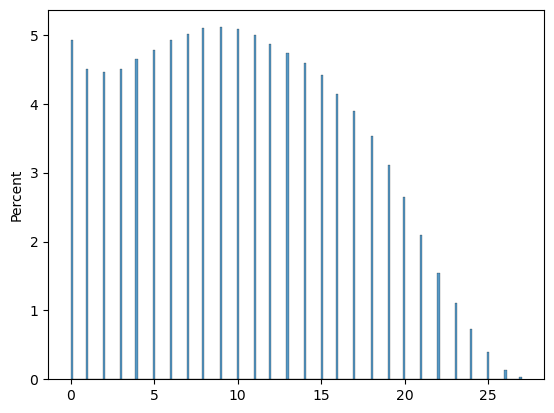

In [9]:
a = np.sum(discretise(A,thr = high_gene_active),axis=1)
sns.histplot(a,stat = 'percent',cumulative=False)
np.quantile(a,q = 0.85)

In [107]:
Counter(np.sum(discretise(a,0.3),axis=1))

Counter({27: 2237077,
         26: 590445,
         25: 262685,
         24: 160087,
         23: 108473,
         22: 78334,
         21: 62944,
         20: 55542,
         19: 51571,
         18: 48900,
         17: 45884,
         16: 41733,
         15: 37162,
         14: 34145,
         13: 31288,
         12: 27889,
         11: 23278,
         10: 19563,
         9: 15296,
         8: 11837,
         7: 8269,
         6: 5090,
         5: 3002,
         4: 1958,
         3: 1091,
         2: 536,
         1: 117})

<Axes: ylabel='Percent'>

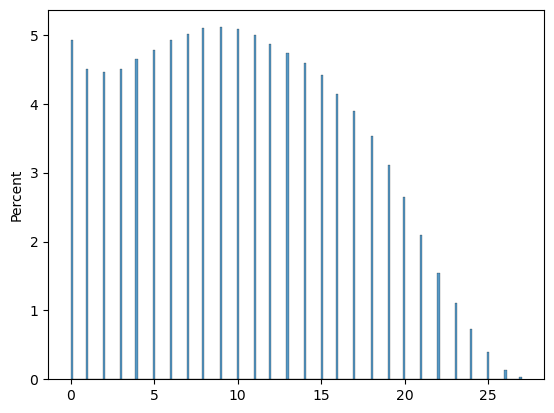

In [11]:
A = discretise(intensities_protein.loc[:,channels],0.5)
sns.histplot(np.sum(A,axis = 1),stat = 'percent')

Show those genes that yield the highest fraction of counts in each single cell, across all cells

KeyboardInterrupt: 

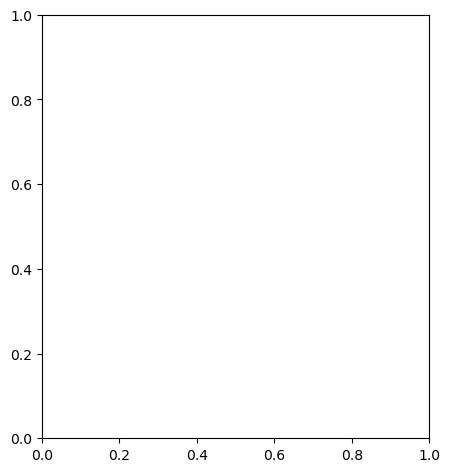

In [12]:
sc.pl.highest_expr_genes(adata, n_top=20, )


In [75]:
adata.raw = adata

In [24]:
#pd.DataFrame(np.quantile(adata.raw.X,0.95,axis = 0),adata.var.index)

normalise every channel independently to the 95 percentile

In [79]:
q = np.quantile(adata.X,q = 0.95,axis = 0)
adata.X = adata.X/q
adata.X[adata.X>1] = 1

If cells have low dna, it is likely that cells are rubbish, so we filter them out

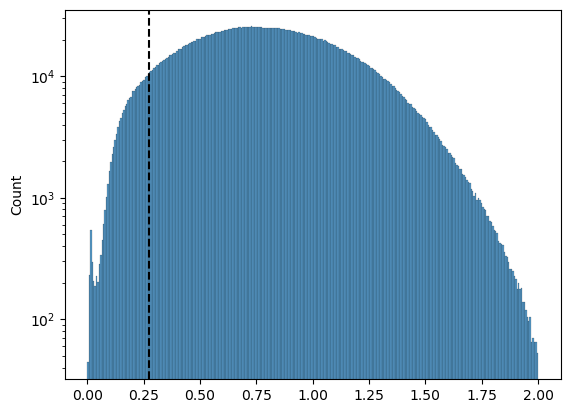

In [13]:
dna_count = adata[:,adata.var.index.isin(['DNA1', 'DNA2'])].X.sum(axis = 1)
sns.histplot(dna_count)
plt.semilogy()
dna_thr = np.quantile(dna_count,0.05)
plt.axvline(dna_thr,ls = '--',c = 'k')

In [68]:
adata=adata[dna_count>dna_thr]

For phenotyping , we  want the cells to express some markers, but not all together at the same time.
We are gonna use lower and higher bounds of total expression. Also remove DNA and Carboplatin as they do not have a role in phenotyping

In [ ]:
adata.raw

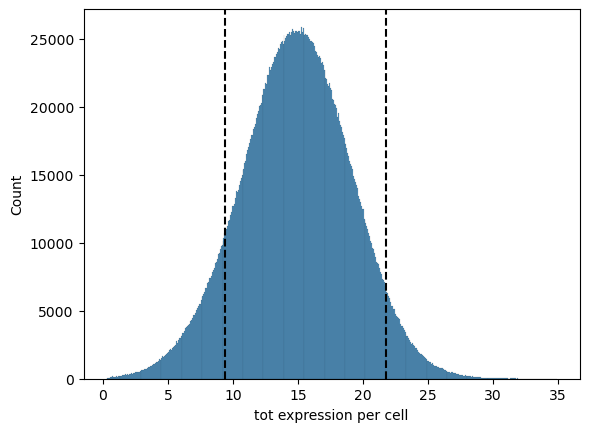

In [14]:
tot_counts = adata[:,~adata.var.index.isin(['DNA1', 'DNA2','Carboplatin'])].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [15]:
adata = adata[(tot_counts>np.quantile(tot_counts,0.10))*(tot_counts<np.quantile(tot_counts,0.95))]

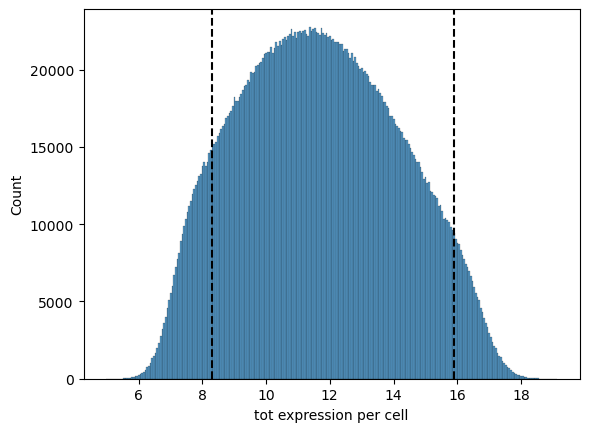

In [16]:
channels = ['CD38', 'CD14', 'Tbet', 'CD16', 'CD163',
       'Pan-keratin', 'CD11b', 'CD107a', 'CD45', 'CD44', 'CD366',
       'FOXP3', 'CD4', 'E-Cadherin', 'CD68', 'HLA-DR-DQ-DP', 'CD20',
       'CD8a', 'Beta-Catenin', 'B7-H4', 'Granzyme-B',
       'CD3', 'CD27', 'CD45RO',
       'Alpha-SMA', 'Vimentin', 'CD31' ]
tot_counts = adata[:,adata.var.index.isin(channels)].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
len(channels)

In [ ]:
adata=adata[adata.obs.total_counts>]


In [ ]:
adata.obs

In [ ]:
low_dna = adata[dna_count<0.1]
tot_counts = low_dna[:,~low_dna.var.index.isin(['DNA1', 'DNA2','Carboplatin'])].X.sum(axis = 1)
sns.histplot(tot_counts)
plt.xlabel('tot expression per cell')
plt.axvline(np.quantile(tot_counts,0.10),c = 'k',ls = '--')
plt.axvline(np.quantile(tot_counts,0.95),c = 'k',ls = '--')

In [ ]:
plt.hist(adata.X.reshape(-1),cumulative=True)

In [ ]:
plt.hist(adata.X.reshape(-1),bins = 30)

In [11]:
def discretise(adata,thr):
    '''binarise the counts to 0/1'''
    return adata.X>thr


In [76]:
adata.raw

In [80]:
dna_count = adata[:,adata.var.index.isin(['DNA1', 'DNA2'])].X.sum(axis = 1)
tot_counts = adata[:,adata.var.index.isin(channels)].X.sum(axis = 1)
tot_genes = discretise(adata[:,adata.var.index.isin(channels)],thr = 0.5).sum(axis = 1)

In [70]:
adata#[tot_genes>1]

View of AnnData object with n_obs × n_vars = 3765986 × 38
    obsm: 'spatial'

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


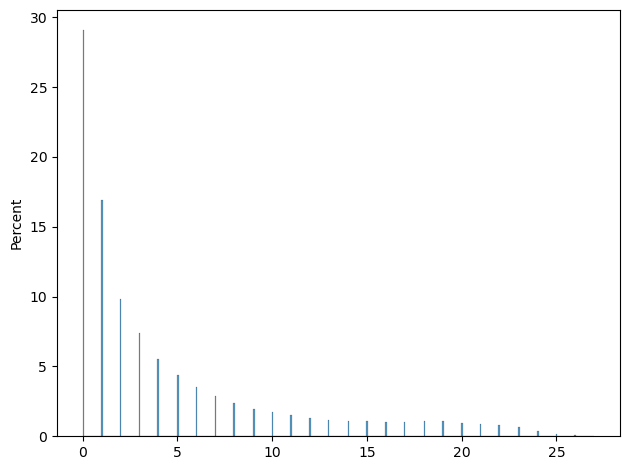

In [81]:
sns.histplot(tot_genes,stat = 'percent')
plt.tight_layout()
#plt.savefig('figures/tot_genes_0.3.png')

In [ ]:
tot

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


array([ 8., 10., 14.])

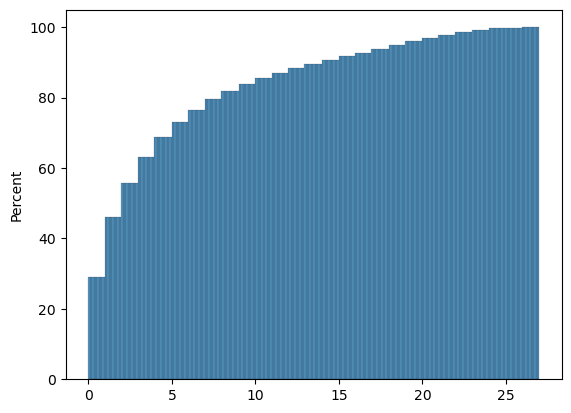

In [66]:
sns.histplot(tot_genes,stat = 'percent',cumulative=True)
np.quantile(tot_genes,q=[0.8,0.85,0.9])

In [67]:
from collections import Counter
k,v = zip(*Counter(tot_genes).items())
v = np.array(v)[np.argsort(k)]
k = np.sort(k)
dict(zip(k,(np.cumsum(v)/np.sum(v))))


{0: 0.2906316942956403,
 1: 0.45986323582385935,
 2: 0.5582799135057903,
 3: 0.6322994624887367,
 4: 0.687604750118309,
 5: 0.7311883670736765,
 6: 0.7662597913927566,
 7: 0.795421063943357,
 8: 0.819157024526537,
 9: 0.8390230957298781,
 10: 0.8560969235628108,
 11: 0.8710419464627884,
 12: 0.8842610203935426,
 13: 0.8960321336281052,
 14: 0.907052527170705,
 15: 0.9176672899120023,
 16: 0.9281655094753135,
 17: 0.9387030812805421,
 18: 0.9492981679008807,
 19: 0.9598932545212194,
 20: 0.9695471666890335,
 21: 0.978650651985926,
 22: 0.9869229473012939,
 23: 0.9936140897170573,
 24: 0.9975109706987243,
 25: 0.999131980356168,
 26: 0.9998208968476836,
 27: 1.0}

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

<Axes: ylabel='Count'>

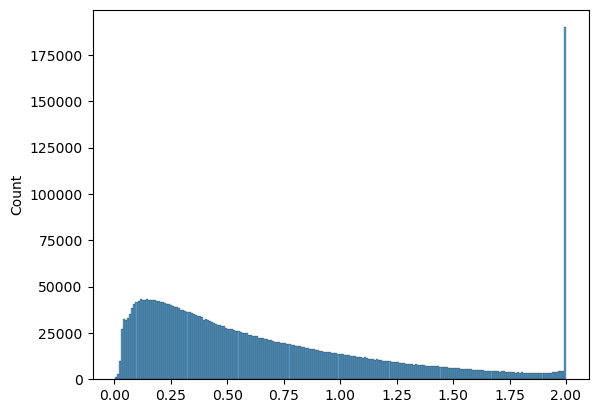

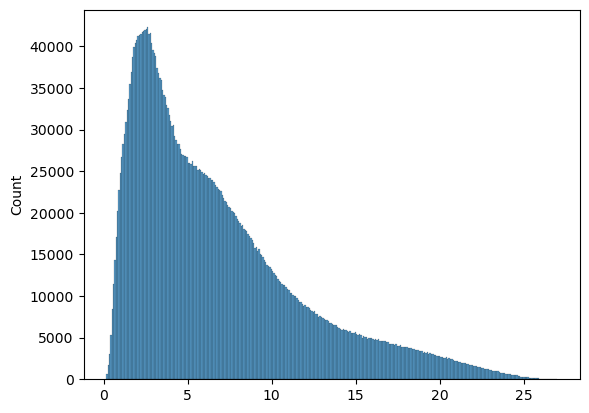

In [12]:
sns.histplot(dna_count)
plt.figure()
sns.histplot(tot_counts).

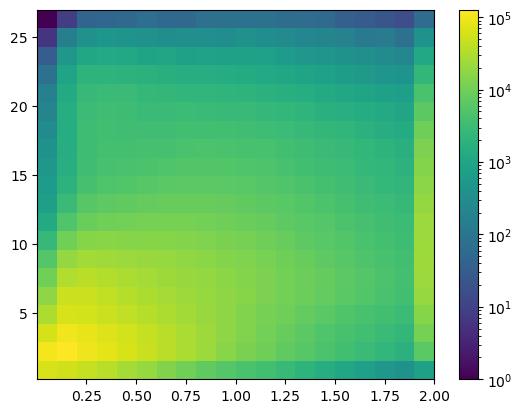

In [41]:
_ = plt.hist2d(dna_count,tot_counts,bins = 20, norm=LogNorm())
plt.colorbar()


<Figure size 640x480 with 0 Axes>

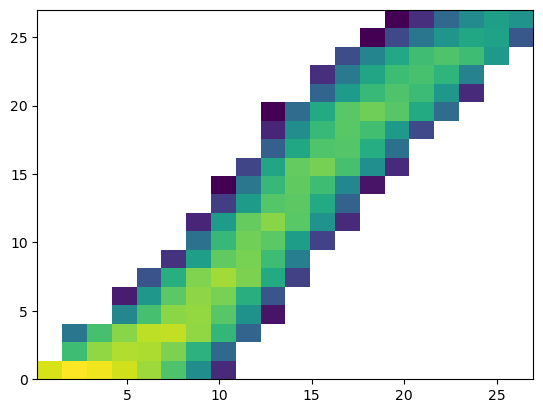

<Figure size 640x480 with 0 Axes>

In [42]:
_ = plt.hist2d(tot_counts, tot_genes,bins = 20, norm=LogNorm())
plt.figure()


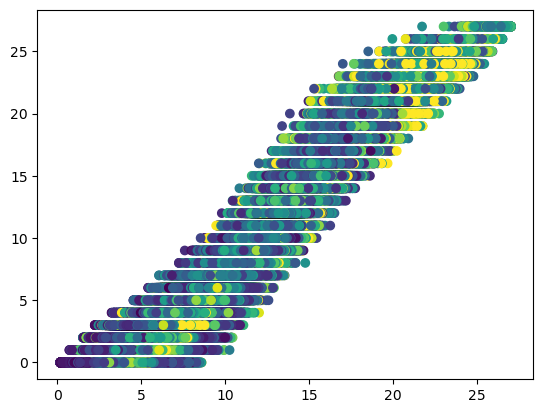

In [20]:
plt.scatter(tot_counts, tot_genes,c = dna_count)

In [61]:
tot_counts = discretise(adata[:,adata.var.index.isin(channels)],thr = 0.3).sum(axis = 1)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Percent'>

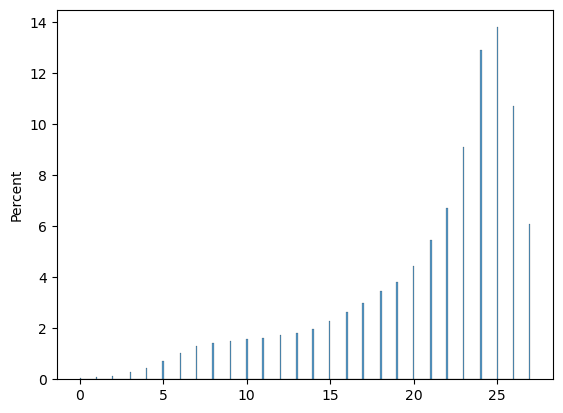

In [62]:
sns.histplot(tot_counts,stat='percent')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/giuseppe/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


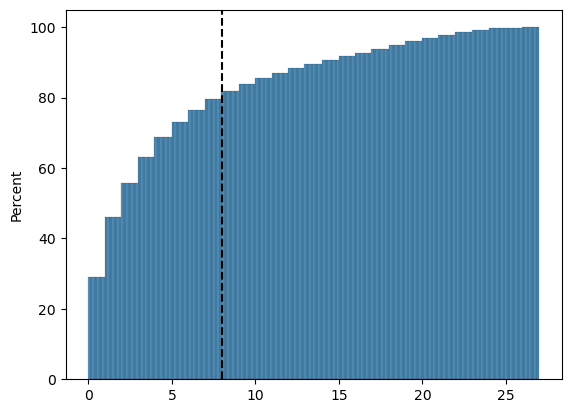

In [201]:
sns.histplot(tot_counts,stat='percent',cumulative=True)
plt.axvline(np.quantile(tot_counts,.80),ls = '--',c ='k')
#plt.axhline(10,ls = '--',c ='k')

In [193]:
np.quantile(tot_counts,0.8)

15.0

In [ ]:
from collections import Counter

In [ ]:
b,c = list(zip(*Counter(tot_counts).items()))

In [ ]:
Counter(a)

In [ ]:
plt.bar(b,np.array(c)/sum(c),0.5)

In [ ]:
plt.bar(np.arange(len(b)),np.cumsum(c)/sum(c),0.5)

(array([  5311.,  49495.,  71402.,  79832.,  91070.,  94535.,  94866.,
         94732.,  94397.,  93466.,  92016.,  90034.,  88310.,  85861.,
         83859.,  81952.,  79513.,  77590.,  75423.,  72346.,  71092.,
         68547.,  66036.,  64197.,  62016.,  60256.,  58649.,  57090.,
         55042.,  53875.,  52017.,  50754.,  49197.,  47998.,  46585.,
         44909.,  44336.,  43141.,  42023.,  40424.,  39438.,  38669.,
         37546.,  36375.,  35133.,  34242.,  32877.,  32283.,  31234.,
         30586.,  29557.,  28781.,  27596.,  26824.,  26320.,  25784.,
         24511.,  23581.,  23359.,  22480.,  21802.,  20912.,  20131.,
         19701.,  18726.,  18429.,  17378.,  17326.,  16466.,  15994.,
         15351.,  15400.,  14441.,  14099.,  13559.,  13301.,  12730.,
         12209.,  11929.,  11653.,  11235.,  10629.,  10238.,   9935.,
          9722.,   9229.,   9325.,   8728.,   8248.,   8224.,   7841.,
          7637.,   7321.,   7119.,   7067.,   7167.,   7907.,   8526.,
      

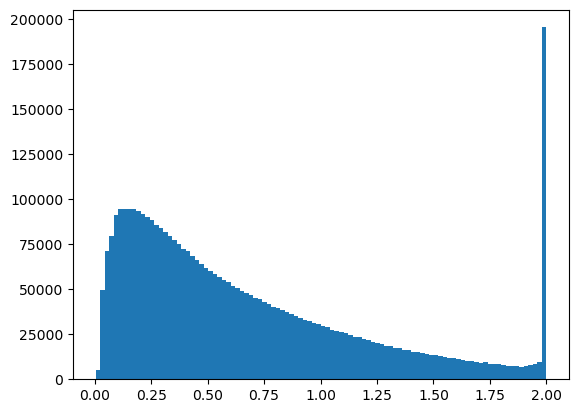

In [213]:
plt.hist(adata[:,adata.var.index.isin(['DNA1','DNA2'])].X.sum(axis = 1),bins = 100)

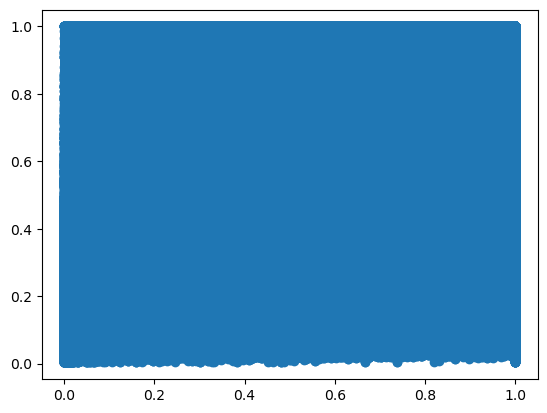

In [75]:
plt.hist2d(adata[:,adata.var.index=='Ki-67'].X.reshape(-1),adata[:,adata.var.index=='DNA1'].X.reshape(-1),norm = )

In [15]:
adata

AnnData object with n_obs × n_vars = 3964196 × 38
    obsm: 'spatial'

In [16]:
cell_table = pd.read_csv(cell_table_path)